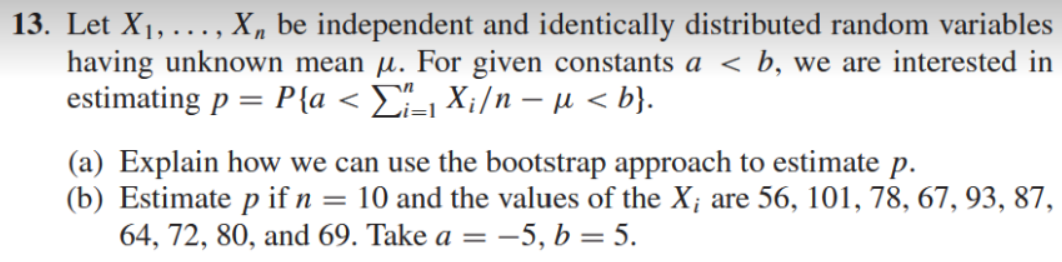

(a) Albert har forklaringen

(b) We now proceed to implement the bootstrapping

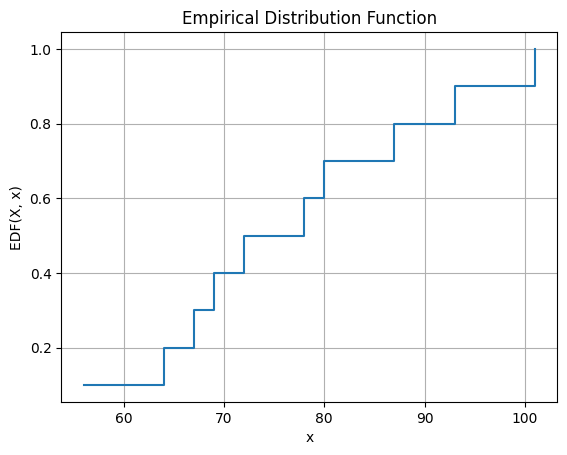

p =  77.5 %


In [ ]:
import numpy as np
import random
X = np.array([56,101,78,67,93,87,64,72,80,69])
a = -5
b = 5

n = 10
mu = np.mean(X)

def Inverse_EDF(X, p):
    sorted_X = np.sort(X)
    index = int(np.ceil(p * n)) - 1
    return sorted_X[index]

def bootstrap_sample_inverse(X):
    n = len(X)
    return np.array([Inverse_EDF(X, random.uniform(0, 1)) for _ in range(n)])

bootstrap_samples = [bootstrap_sample_inverse(X) for _ in range(1000)]

accepted = 0
for sample in bootstrap_samples:
    theta = np.mean(sample) - mu
    if a <= theta <= b:
        accepted += 1
print("p = ",(accepted / len(bootstrap_samples))*100, "%")

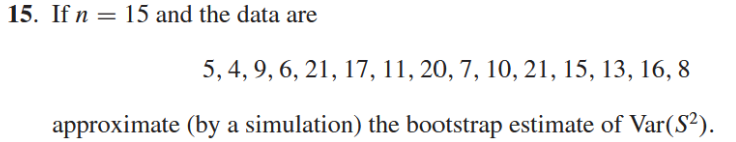

In [35]:
import numpy as np
import random
random.seed(42)
np.random.seed(42)
n = 15
X = np.array([5,4,9,6,21,17,11,20,7,10,21,15,13,16,8])

k = 1000

bootstrap_samples = [bootstrap_sample_inverse(X) for _ in range(k)]

var_estimates = []
for sample in bootstrap_samples:
    theta = np.var(sample, ddof=1)
    var_estimates.append(theta)
var_estimates = np.array(var_estimates)
mean_var_estimate = np.mean(var_estimates)
print("Mean of Variance Estimates: ", np.var(X, ddof=1))
variance_estimate = np.var(var_estimates, ddof=1)
print("Estimated Variance of the Variance Estimator: ", variance_estimate)

Mean of Variance Estimates:  34.31428571428571
Estimated Variance of the Variance Estimator:  56.68780166788104


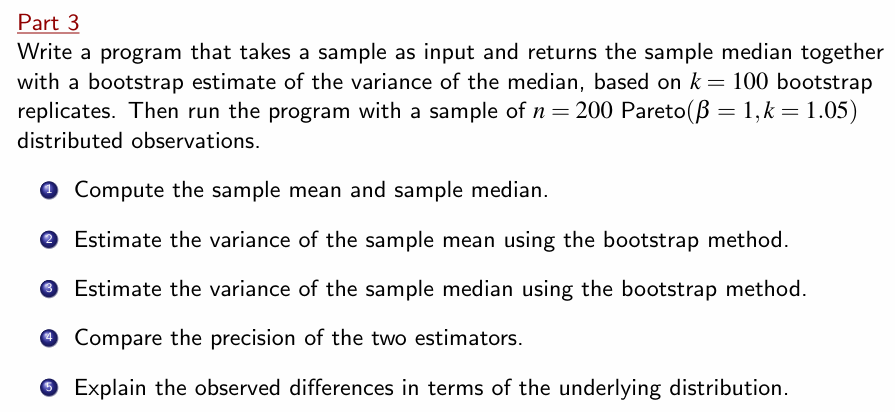

Sample Mean:  4.225954964437149
Sample Median:  1.914960542162116
Estimated Variance of the Sample Mean:  0.2776063673236822
Estimated Variance of the Sample Median:  0.022530789879032093


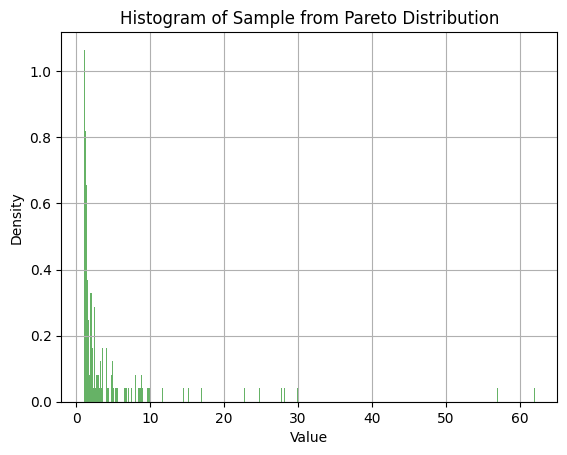

In [40]:
import numpy as np
import random
import matplotlib.pyplot as plt
import scipy as sp
# Set seed'
random.seed(42)
np.random.seed(42)
n = 200
k = 100

def sample_pareto(beta, k, size=1):
    U = np.random.uniform(0, 1, size=size)
    return k * (U ** (-1/beta))

X = sample_pareto(beta=1, k=1.05, size=200)
X = sp.stats.pareto.rvs(b=1.05, scale=1, size=200, random_state=42)
sample_mean = np.mean(X)
sample_median = np.median(X)
print("Sample Mean: ", sample_mean)
print("Sample Median: ", sample_median)

bootstrap_samples = [bootstrap_sample_inverse(X) for _ in range(100)]

mean_estimates = []
median_estimates = []
for sample in bootstrap_samples:
    mean_estimates.append(np.mean(sample))
    median_estimates.append(np.median(sample))

mean_var_estimate = np.var(mean_estimates, ddof=1)
median_var_estimate = np.var(median_estimates, ddof=1)
print("Estimated Variance of the Sample Mean: ", mean_var_estimate)
print("Estimated Variance of the Sample Median: ", median_var_estimate)

# plot sample
plt.hist(X, bins=500, density=True, alpha=0.6, color='g')
plt.title('Histogram of Sample from Pareto Distribution')
plt.xlabel('Value')
plt.ylabel('Density')
plt.grid()
plt.show()
